In [1]:
import os
print(os.getcwd())

c:\Users\SUDESHNA ROUL\OneDrive\Desktop\project


In [2]:
import pandas as pd
df=pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [4]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [5]:
failures=df[df['Machine failure']==1]
failures.shape

(339, 14)

In [6]:
print("average of failure temp",failures['Air temperature [K]'].mean())
print("average of df temperatures",df['Air temperature [K]'].mean())

average of failure temp 300.88643067846607
average of df temperatures 300.00493


In [7]:
healthy=df[df['Machine failure']==0]
healthy.shape


(9661, 14)

In [8]:
print("mean of healthy data values",healthy['Air temperature [K]'].mean())

mean of healthy data values 299.9739985508746


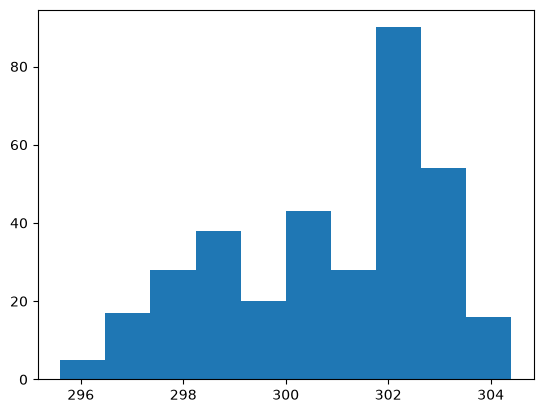

In [9]:
import matplotlib.pyplot as plt
plt.hist(failures['Air temperature [K]'])
plt.show()

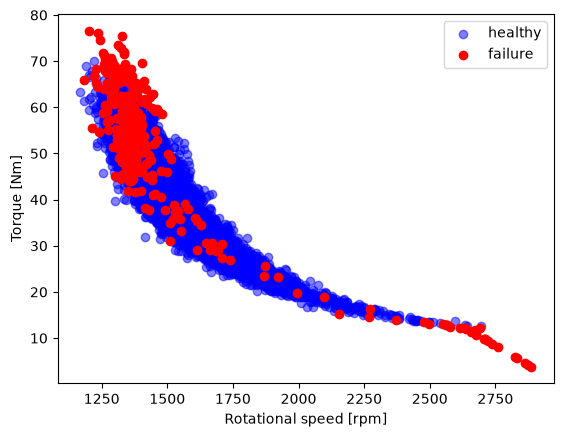

In [10]:
import matplotlib.pyplot as plt
plt.scatter(healthy['Rotational speed [rpm]'],healthy['Torque [Nm]'],color='blue',label='healthy',alpha=0.5)
plt.scatter(failures['Rotational speed [rpm]'],failures['Torque [Nm]'],color='red',label='failure')
plt.xlabel('Rotational speed [rpm]')
plt.ylabel('Torque [Nm]')
plt.legend()
plt.show()

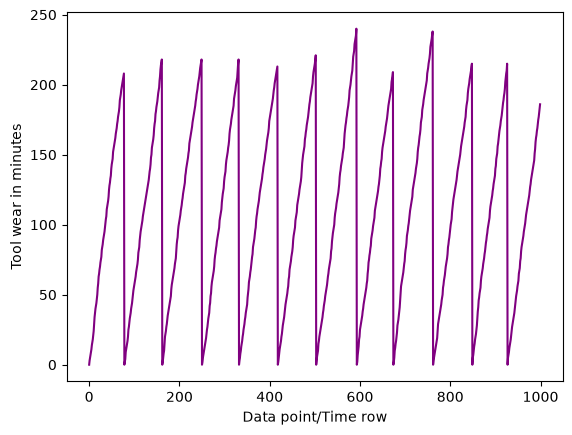

In [11]:
plt.plot(df['Tool wear [min]'][:1000],color='purple')
plt.ylabel('Tool wear in minutes')
plt.xlabel('Data point/Time row')
plt.show() 

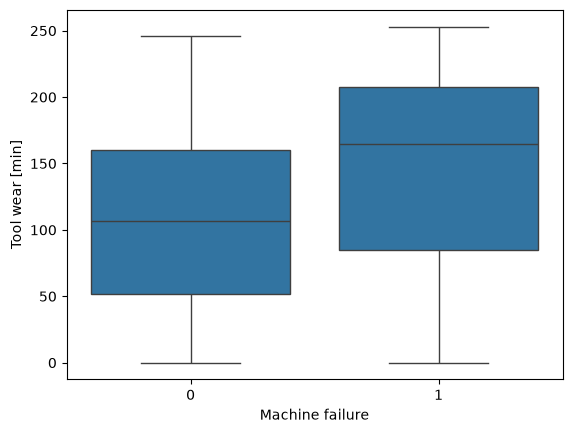

In [12]:
import seaborn as sns
sns.boxplot(x=df['Machine failure'],y=df['Tool wear [min]'])
plt.show()

In [13]:
cleaned_df=df.drop(columns=['UDI','Product ID','Type'])
x=cleaned_df.drop(columns=['Machine failure','TWF','HDF','PWF','OSF','RNF'])
y=cleaned_df['Machine failure']
print(x.shape)
print(y.shape)

(10000, 5)
(10000,)


In [14]:
from sklearn.tree import DecisionTreeClassifier
my_first_ai=DecisionTreeClassifier()
print("AI model succesfully initialized and waiting for data")

AI model succesfully initialized and waiting for data


In [15]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42,shuffle=True)
print(x_train.shape)
print(x_test.shape)

(8000, 5)
(2000, 5)


In [16]:
my_first_ai.fit(x_train,y_train)
predictions=my_first_ai.predict(x_test)
print(predictions)

[0 0 0 ... 0 1 0]


In [17]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,predictions)
print("final exam score",score)

final exam score 0.9785


In [18]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,predictions))
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

[[1914   25]
 [  18   43]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1939
           1       0.63      0.70      0.67        61

    accuracy                           0.98      2000
   macro avg       0.81      0.85      0.83      2000
weighted avg       0.98      0.98      0.98      2000



In [19]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(x_train,y_train)
rf_predictions=rf_model.predict(x_test)
print(classification_report(y_test,rf_predictions))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.82      0.59      0.69        61

    accuracy                           0.98      2000
   macro avg       0.90      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000

